In [1]:
import cartopy.crs as ccrs # module to work with coordinate reference systems for mapping
import cartopy.feature as cfeature # module to add details like country and state outlines to maps
import matplotlib.pyplot as plt # major plotting module
import metpy # library for working with meteorological data
import xarray as xr # library for working with labeled higher-dimensional data

In [2]:
# You will need to open a terminal from your current working directory (the directory with this
# notebook) and run the command: cp /data/metr1313/kis/graphcastgfs.t00z.pgrb2.0p25_251029.f000 .
# This will copy the data file into your current working directory
# The period is part of the command and stands for the current working directory!

ds = xr.open_dataset('graphcastgfs.t00z.pgrb2.0p25_251029.f000', # data file
                      engine='cfgrib', # data file is in GRIB2 format
                      decode_timedelta=False, # to avoid a User Warning
                      backend_kwargs={'filter_by_keys':{'typeOfLevel':'isobaricInhPa'}}) # to avoid a User Warning

Ignoring index file 'graphcastgfs.t00z.pgrb2.0p25_251029.f000.5b7b6.idx' older than GRIB file


In [3]:
# Let's view the dataset!
# Please explore it by clicking on its icons to expand its metadata and values
ds

<xarray.Dataset> Size: 324MB
Dimensions:        (isobaricInhPa: 13, latitude: 721, longitude: 1440)
Coordinates:
    time           datetime64[ns] 8B ...
    step           float64 8B ...
  * isobaricInhPa  (isobaricInhPa) float64 104B 1e+03 925.0 850.0 ... 100.0 50.0
  * latitude       (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude      (longitude) float64 12kB 0.0 0.25 0.5 ... 359.3 359.5 359.8
    valid_time     datetime64[ns] 8B ...
Data variables:
    gh             (isobaricInhPa, latitude, longitude) float32 54MB ...
    q              (isobaricInhPa, latitude, longitude) float32 54MB ...
    t              (isobaricInhPa, latitude, longitude) float32 54MB ...
    u              (isobaricInhPa, latitude, longitude) float32 54MB ...
    v              (isobaricInhPa, latitude, longitude) float32 54MB ...
    w              (isobaricInhPa, latitude, longitude) float32 54MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-03-04T10:32 GRIB to CDM+CF via cfgrib-0.9.1...

In [4]:
variables = ['gh', 'u', 'v'] # We only want to plot geopotential height, u, and v
ds_subset = ds.sel(
    isobaricInhPa=500, # We only will plot data on the 500 hPa surface
    latitude=slice(70,20),
    longitude=slice(200,300))[variables]

In [5]:
ds_subset

<xarray.Dataset> Size: 970kB
Dimensions:        (latitude: 201, longitude: 400)
Coordinates:
    time           datetime64[ns] 8B ...
    step           float64 8B ...
    isobaricInhPa  float64 8B 500.0
  * latitude       (latitude) float64 2kB 70.0 69.75 69.5 ... 20.5 20.25 20.0
  * longitude      (longitude) float64 3kB 200.0 200.3 200.5 ... 299.5 299.8
    valid_time     datetime64[ns] 8B ...
Data variables:
    gh             (latitude, longitude) float32 322kB ...
    u              (latitude, longitude) float32 322kB ...
    v              (latitude, longitude) float32 322kB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-03-04T10:32 GRIB to CDM+CF via cfgrib-0.9.1...

In [6]:
time = str(ds_subset['time'].values)
print(time)

2025-10-29T00:00:00.000000000


In [7]:
speed = metpy.calc.wind_speed(ds_subset['u'], ds_subset['v'])

In [8]:
ug, vg = metpy.calc.geostrophic_wind(ds_subset['gh'])

/var/folders/qf/fw7pglk504l3t6b_wqjq01140000gp/T/ipykernel_17192/1034174444.py:1: UserWarning: More than one time coordinate present for variable  "gh".
  ug, vg = metpy.calc.geostrophic_wind(ds_subset['gh'])


In [9]:
ug.shape

(201, 400)

In [10]:
#ua, va = metpy.calc.ageostrophic_wind(ds_subset['gh'], ds_subset['u'], ds_subset['v'])

In [11]:
transform = ccrs.PlateCarree()
projection = ccrs.PlateCarree()

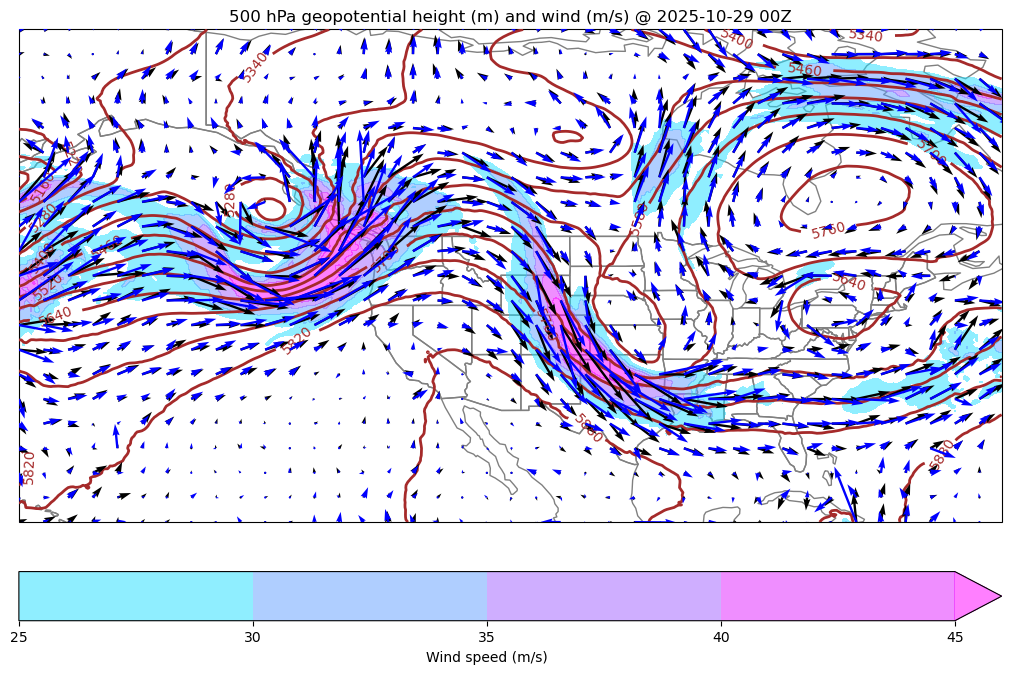

In [12]:
fig, ax = plt.subplots(
    figsize=(10,10),
    layout='constrained',
    subplot_kw={'projection':projection}
)

ax.add_feature(cfeature.BORDERS, edgecolor='gray', zorder=1)
ax.add_feature(cfeature.COASTLINE, edgecolor='gray', zorder=1)
ax.add_feature(cfeature.STATES, edgecolor='gray', zorder=1)

gh_levels = range(4800, 6060, 60)
gh_contours = ax.contour(
    ds_subset['longitude'],
    ds_subset['latitude'],
    ds_subset['gh'],
    transform=transform,
    levels=gh_levels,
    colors='brown',
    linewidths=2,
    zorder=3,
)
ax.clabel(gh_contours)

quiver_step = 10
mask = slice(None, None, quiver_step)
geo_vectors = ax.quiver(
    ds_subset['longitude'][mask],
    ds_subset['latitude'][mask],
    ug[mask,mask],
    vg[mask,mask],
    transform=transform,
    #scale=800,
    color='blue',
    zorder=5,
)

wind_vectors = ax.quiver(
    ds_subset['longitude'][mask],
    ds_subset['latitude'][mask],
    ds_subset['u'][mask,mask],
    ds_subset['v'][mask,mask],
    transform=transform,
    #scale=geo_vectors.scale,
    color='black',
    zorder=4,           
)

#ageo_vectors = ax.quiver(
#    ds_subset['longitude'][mask],
#    ds_subset['latitude'][mask],
#    ua[mask,mask],
#    va[mask,mask],
#    transform=transform,
#    scale=geo_vectors.scale,
#    color='red',
#    zorder=4,           
#)

isotach_levels = range(25, 50, 5)
isotachs = ax.contourf(
    ds_subset['longitude'],
    ds_subset['latitude'],
    speed,
    transform=transform,
    levels=isotach_levels,
    cmap='cool',
    alpha=0.5,
    extend='max',
    zorder=2,
)
cbar = fig.colorbar(
    isotachs,
    location='bottom',
    orientation='horizontal',
    #drawedges=True,
    label='Wind speed (m/s)',
)

ax.set_title(f'500 hPa geopotential height (m) and wind (m/s) @ {time[:10]} {time[11:13]}Z')

fig.savefig(
    'my_500-hPa_plot.png',
    format='png',
    bbox_inches='tight',
)

plt.show()